# Heart Disease Prediction

Dataset from kaggle - has 302 patient records with medical info like age, cholesterol, blood pressure etc. Target column tells if the person has heart disease or not.

Trying logistic regression and a neural network and comparing which one does better.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

## Load Data

Features in the dataset:
- age, sex, cp (chest pain type 0-3)
- trestbps (resting blood pressure), chol (cholesterol), fbs (fasting blood sugar)
- restecg (resting ECG results), thalach (max heart rate)
- exang (exercise induced angina), oldpeak (ST depression)
- slope, ca (number of major vessels 0-3), thal (blood disorder type)
- target - 1 = heart disease, 0 = no heart disease

In [2]:
df = pd.read_csv('heart.csv')
print(df.shape)
# print(df.columns)
df.head()

(302, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


In [4]:
df['target'].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [5]:
# drop missing if any
before = df.shape[0]
df = df.dropna()
after = df.shape[0]

print("dropped", before - after, "rows")
print("left with", after)

dropped 0 rows
left with 302


## EDA

checking basic stats, if the classes are balanced, and how the features correlate with each other

In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


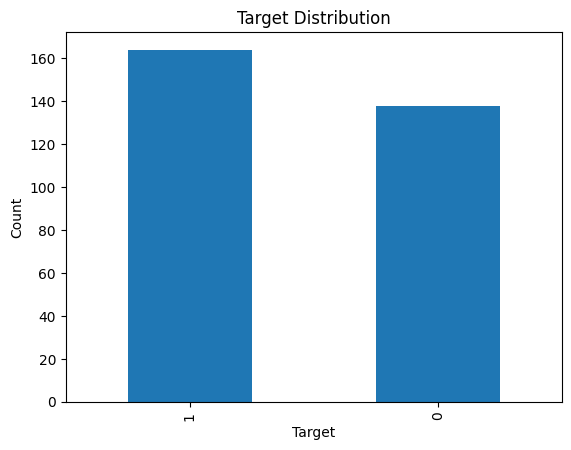

In [23]:
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.savefig('obtained_fig/target_distribution.png', bbox_inches='tight')
plt.show()

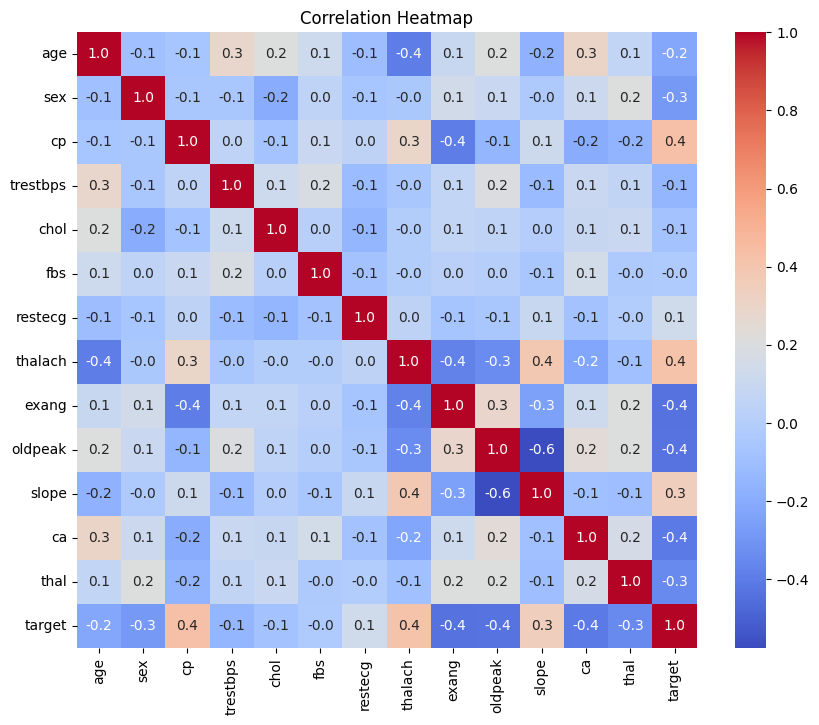

In [24]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Heatmap')
plt.savefig('obtained_fig/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Preprocessing

splitting into X (features) and y (target), then 80/20 train test split. using stratify so both sets have same ratio of disease/no disease.

also scaling with StandardScaler because features like cholesterol are in hundreds while sex is just 0 or 1, and models like LR and neural nets are sensitive to that

In [9]:
X = df.drop('target', axis=1)
y = df['target']

In [10]:
# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 241 | test: 61


In [11]:
# scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

its actually a classification model not regression (confusing name). it uses sigmoid to output a probability between 0 and 1.

using GridSearchCV to try different values of C (regularization) and penalty (l1/l2) and it picks whichever combo gives the best result. cv=5 means it does 5-fold cross validation

In [12]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=5)
lr_grid.fit(X_train_scaled, y_train)

best_lr = lr_grid.best_estimator_
print("best params:", lr_grid.best_params_)

best params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


In [13]:
y_pred_lr = best_lr.predict(X_test_scaled)
y_pred_lr_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_pred_lr_proba)

print("accuracy:", round(lr_accuracy, 3))
print("precision:", round(lr_precision, 3))
print("recall:", round(lr_recall, 3))
print("f1:", round(lr_f1, 3))
print("auc:", round(lr_auc, 3))
print()
print(classification_report(y_test, y_pred_lr))

accuracy: 0.803
precision: 0.8
recall: 0.848
f1: 0.824
auc: 0.859

              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



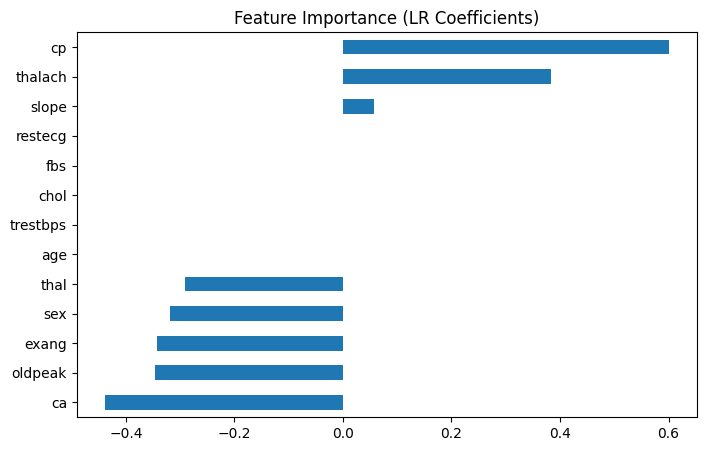

In [25]:
coefs = pd.Series(best_lr.coef_[0], index=X.columns)
coefs = coefs.sort_values()

coefs.plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance (LR Coefficients)')
plt.savefig('obtained_fig/feature_importance.png', bbox_inches='tight')
plt.show()

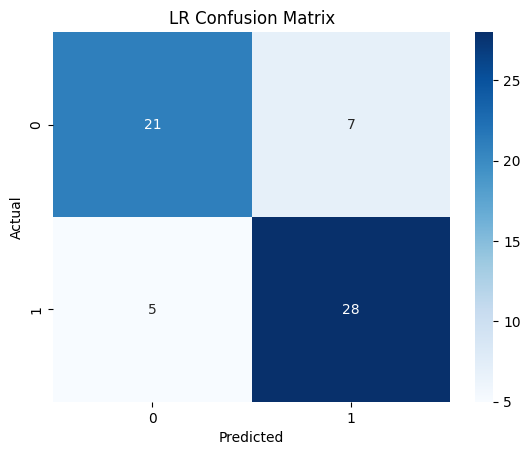

In [26]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('LR Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('obtained_fig/lr_confusion_matrix.png', bbox_inches='tight')
plt.show()

## ANN

building a simple neural network. first layer has 64 neurons with relu activation, then dropout of 0.3 to prevent overfitting, then 32 neurons, and output layer with sigmoid (gives probability 0 to 1).

using adam optimizer and binary_crossentropy as loss function since its a binary classification problem

In [16]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(13,)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0
)

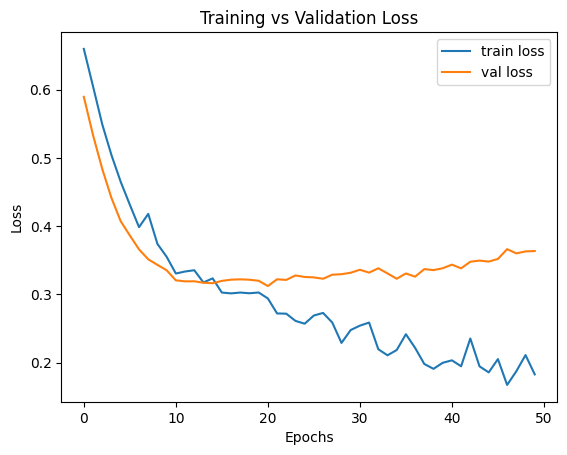

In [27]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.savefig('obtained_fig/training_loss.png', bbox_inches='tight')
plt.show()

In [19]:
y_pred_ann_proba = model.predict(X_test_scaled)
y_pred_ann_proba = y_pred_ann_proba.flatten()

y_pred_ann = (y_pred_ann_proba > 0.5).astype(int)

ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)
ann_auc = roc_auc_score(y_test, y_pred_ann_proba)

print("accuracy:", round(ann_accuracy, 3))
print("precision:", round(ann_precision, 3))
print("recall:", round(ann_recall, 3))
print("f1:", round(ann_f1, 3))
print("auc:", round(ann_auc, 3))
print()
print(classification_report(y_test, y_pred_ann))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
accuracy: 0.754
precision: 0.765
recall: 0.788
f1: 0.776
auc: 0.833

              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



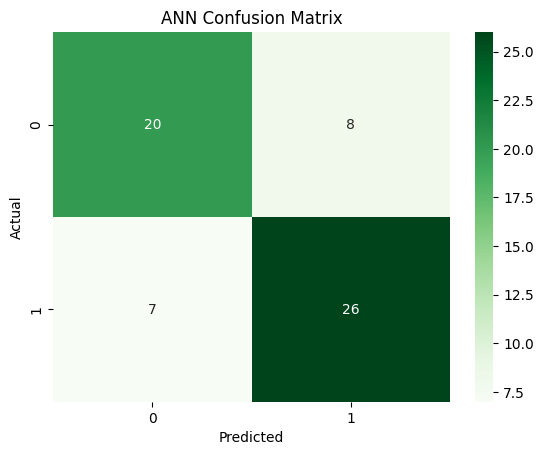

In [28]:
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens')
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('obtained_fig/ann_confusion_matrix.png', bbox_inches='tight')
plt.show()

## Compare

comparing both models on accuracy, precision, recall, f1 and auc. also plotting roc curves to see which model separates the classes better

In [21]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Neural Network'],
    'Accuracy': [lr_accuracy, ann_accuracy],
    'Precision': [lr_precision, ann_precision],
    'Recall': [lr_recall, ann_recall],
    'F1': [lr_f1, ann_f1],
    'AUC': [lr_auc, ann_auc]
})

results

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.803279,0.800000,0.848485,0.823529,0.859307
1,Neural Network,0.754098,0.764706,0.787879,0.776119,0.833333


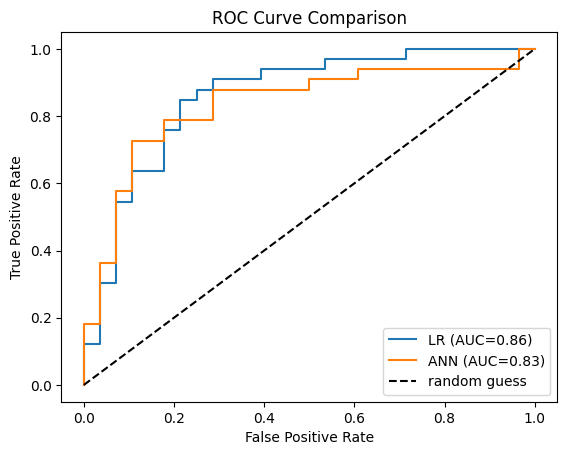

In [29]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_ann_proba)

plt.plot(fpr_lr, tpr_lr, label='LR (AUC=' + str(round(lr_auc, 2)) + ')')
plt.plot(fpr_ann, tpr_ann, label='ANN (AUC=' + str(round(ann_auc, 2)) + ')')
plt.plot([0, 1], [0, 1], 'k--', label='random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('obtained_fig/roc_curve_comparison.png', bbox_inches='tight')
plt.show()

## Conclusion

both models gave similar results which makes sense because the dataset is pretty small (only 302 rows). logistic regression is nice because the coefficients show which features matter. the neural network didnt really do better here, probably because theres not enough data for it to learn anything extra. with a bigger dataset the ANN might do better